# <center>__Title :End-to-End Steel Surface Defect Detection System using Deep Learning, FastAPI, Streamlit and Docker.__</center>

In [1]:
import sys
print(sys.version)

3.10.20 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:42:35) [MSC v.1942 64 bit (AMD64)]


In [2]:
import platform
print(platform.python_version())

3.10.20


In [3]:
import tensorflow as tf

print(tf.__version__)

2.21.0


## __Problem Statement__ :

Steel surface defects can significantly impact product quality and manufacturing efficiency in industrial production. Manual inspection is time-consuming, expensive, and prone to human error, especially when dealing with large volumes of steel sheets. The objective of this project is to develop an automated deep learning-based system capable of detecting and classifying different types of steel surface defects from images. The system aims to improve inspection accuracy, reduce manual effort, and provide real-time defect prediction through a deployable application using FastAPI, Streamlit, and Docker.

## __Project Summary__ :

This project focuses on developing an end-to-end deep learning system for automated steel surface defect detection and classification. Using the NEU Surface Defect Dataset, the project involves data exploration, image preprocessing, model development, performance evaluation, and deployment. Multiple deep learning approaches, including ANN, CNN, regularization techniques, data augmentation, and transfer learning models, will be explored and compared to identify the best-performing architecture. The final solution will provide real-time defect prediction through a Streamlit user interface and FastAPI backend, with Docker used for containerized deployment. The project aims to demonstrate practical skills in computer vision, deep learning, model optimization, API development, and MLOps fundamentals.

## __Dataset Information__ :


#### Dataset Name :

NEU Surface Defect Database

#### Dataset Description :

The NEU Surface Defect Database is a publicly available industrial image dataset designed for steel surface defect classification tasks. It contains grayscale images of steel surfaces with different types of manufacturing defects. The dataset is widely used for research and development in computer vision and deep learning-based defect detection systems.

#### Number of Classes :

The dataset consists of 6 defect classes:

1. Crazing (Cr)
2. Inclusion (In)
3. Patches (Pa)
4. Pitted Surface (PS)
5. Rolled-in Scale (RS)
6. Scratches (Sc)

#### Number of Images :

* Total Images: 1,800
* Images per Class: 300
* Dataset Type: Balanced Dataset

#### Image Characteristics :

* Image Type: Grayscale Images
* Image Resolution: 200 × 200 pixels
* File Format: JPG

#### Dataset Structure :

The dataset is organized into separate folders corresponding to each defect category. Each folder contains images belonging to a specific defect class, making it suitable for supervised image classification tasks.

#### Reason for Dataset Selection :

This dataset was selected because it represents a real-world industrial quality inspection problem. It provides a balanced distribution of defect categories and is well-suited for learning image preprocessing, deep learning, transfer learning, model evaluation, and deployment techniques. The dataset size is manageable for experimentation while still being sufficiently complex to demonstrate practical computer vision skills.


## __GitHub Link__ :

https://github.com/chetansgode/NEU_Surface_Defect_Detection_Project.git

## __Import Libraries__ :

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import os 
import cv2 
import tensorflow as tf 
from tensorflow import keras 
from tensorflow.keras import layers,Sequential

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import  classification_report, confusion_matrix, accuracy_score 
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.applications.mobilenet_v2 import (
    MobileNetV2,
    preprocess_input
)
from tensorflow.keras.models import load_model,save_model
import warnings 
warnings.filterwarnings("ignore")


## __Loading Dataset__ : 

In [2]:
#path
train_dir = "C:/Users/Cheta/Desktop/steel_defect_project/data/NEU-DET/train/images"
test_dir = "C:/Users/Cheta/Desktop/steel_defect_project/data/NEU-DET/validation/images"

In [3]:
# use this method of loading image file during model training

train_df=tf.keras.utils.image_dataset_from_directory(train_dir,
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256))

test_df=tf.keras.utils.image_dataset_from_directory(test_dir,
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256)) 

# def process(image,label):
#     image=tf.cast(image/255,tf.float32)
#     return image,label 

# class_names = train_df.class_names
# train_df=train_df.map(process)
# test_df=test_df.map(process)

Found 1440 files belonging to 6 classes.
Found 360 files belonging to 6 classes.


In [4]:
#for EDA use this method of loading data 

#Check Number of Classes 
classes = os.listdir(train_dir)

print(classes)
print("Number of Classes:", len(classes))

['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
Number of Classes: 6


In [5]:
# Count Images Per Class
print("Count Images Per Class for training :-")
for cls in classes:
    path = os.path.join(train_dir, cls)

    print(
        cls,
        len(os.listdir(path))
    )

print("\nCount Images Per Class for testing :-")
for cls in classes:
    path = os.path.join(test_dir, cls)

    print(
        cls,
        len(os.listdir(path))
    )

Count Images Per Class for training :-
crazing 240
inclusion 240
patches 240
pitted_surface 240
rolled-in_scale 240
scratches 240

Count Images Per Class for testing :-
crazing 60
inclusion 60
patches 60
pitted_surface 60
rolled-in_scale 60
scratches 60


## __Variables Description__ :

ClassName	        Description 

Crazing	     -     Surface cracks appearing as fine irregular lines.

Inclusion	 -     Foreign material trapped within the steel surface.

Patches	      -    Irregular patch-like defects on the surface.

Pitted Surface	-  Small pits or cavities present on the steel surface.

Rolled-in Scale	-  Oxide scale pressed into the steel during rolling.

Scratches	   -   Linear marks or scratches on the steel surface.

## __Exploratory Data Analysis (EDA)__ :

### 1) Check whether the dataset is balanced across defect classes.

In [6]:
#Create DataFrame 
data=[]
for cls in classes:
    class_path = os.path.join(train_dir, cls)
    for img in os.listdir(class_path):
        data.append([os.path.join(class_path, img),cls])

#create dataframe
df = pd.DataFrame(
    data,
    columns=["image_path", "label"]
)

df.head()

,image_path,label
0,C:/Users/Cheta/Desktop/steel_defect_project/da...,crazing
1,C:/Users/Cheta/Desktop/steel_defect_project/da...,crazing
2,C:/Users/Cheta/Desktop/steel_defect_project/da...,crazing
3,C:/Users/Cheta/Desktop/steel_defect_project/da...,crazing
4,C:/Users/Cheta/Desktop/steel_defect_project/da...,crazing


In [7]:
#check diff categories name
print(f"Different classes of defect : \n\t{df.label.unique().tolist()}") 


Different classes of defect : 
	['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


In [8]:
#count total images belong to different category

total_img_classwise=df.label.value_counts().reset_index()
print('Total_img_classwise :')
print(total_img_classwise)

Total_img_classwise :
             label  count
0          crazing    240
1        inclusion    240
2          patches    240
3   pitted_surface    240
4  rolled-in_scale    240
5        scratches    240


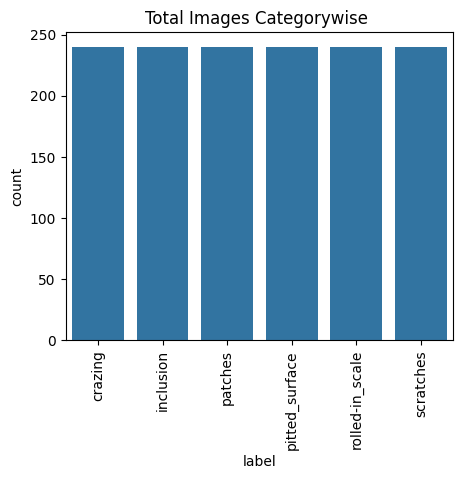

In [9]:
plt.figure(figsize=(5,4))
sns.barplot(x=total_img_classwise['label'],y=total_img_classwise['count'])
plt.title('Total Images Categorywise ')
plt.xticks(rotation=90)
plt.show()


* The dataset contains 6 defect classes. 

* Each class contains 240 training and 60 testing numbers of images, indicating a balanced dataset.

* The dataset is suitable for multi-class image classification tasks.

### 2) Display One Sample Image from Each Class

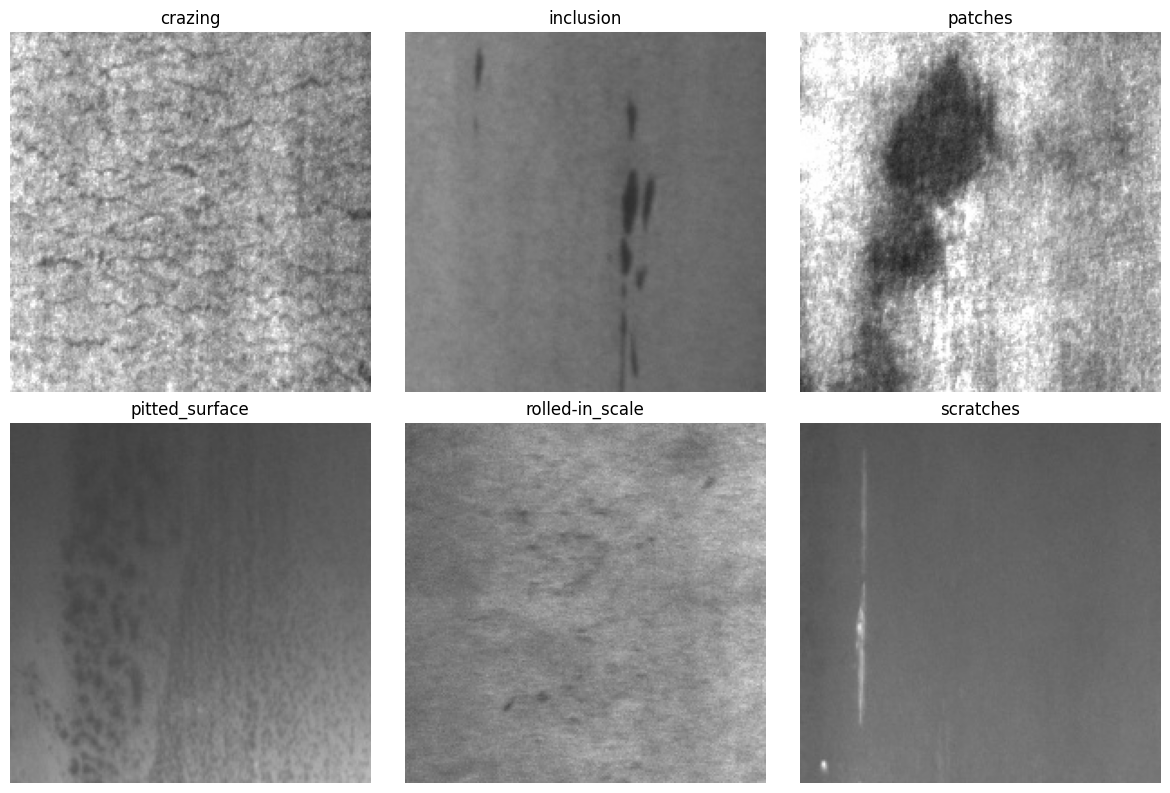

In [10]:
plt.figure(figsize=(12, 8))

for i, cls in enumerate(classes):

    class_path = os.path.join(train_dir, cls)

    img_name = os.listdir(class_path)[0]

    img_path = os.path.join(class_path, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

### 3) Image Dimension Analysis

In [11]:
image_shapes = []

for cls in classes:

    class_path = os.path.join(train_dir, cls)

    for img_name in os.listdir(class_path)[:20]:   # sample images

        img_path = os.path.join(class_path, img_name)

        img = cv2.imread(img_path)

        image_shapes.append(img.shape)

print("Unique shape of images -",set(image_shapes))

Unique shape of images - {(200, 200, 3)}


* All images are 200×200
*  There is 3 Channels (RGB) 

### 4) Pixel Intensity Distribution Analysis

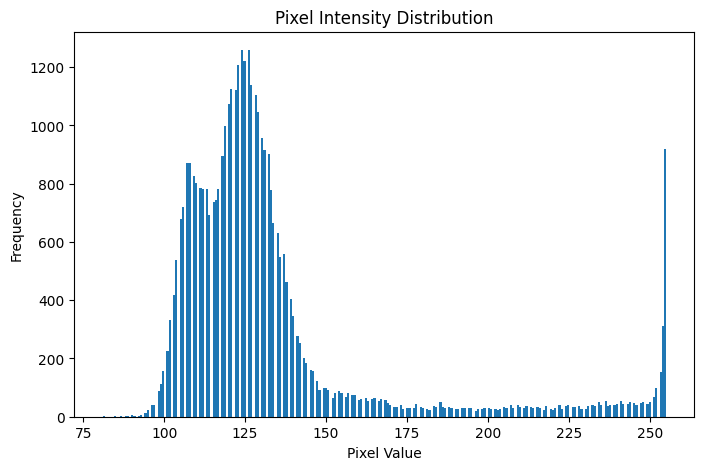

In [12]:
#check for single image
sample_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)   #3d to 1d (rgb>greyscale)

plt.figure(figsize=(8,5))

plt.hist(sample_img.ravel(), bins=256)   #.ravel() converts the 2D matrix into a 1D array

plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")

plt.show()

In [13]:
# now check for sample images of all category 
all_pixels = []

for cls in classes:

    class_path = os.path.join(train_dir, cls)

    for img_name in os.listdir(class_path)[:20]:   # 20 images per class

        img_path = os.path.join(class_path, img_name)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        all_pixels.extend(img.ravel())

print(len(all_pixels))

4800000


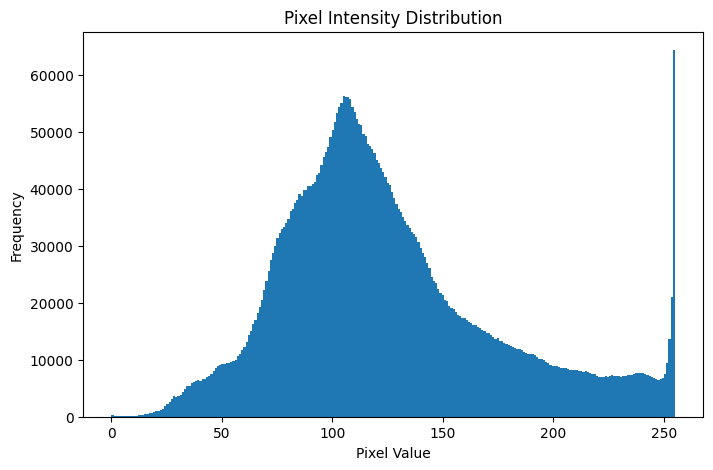

In [14]:
plt.figure(figsize=(8,5))

plt.hist(all_pixels, bins=256)

plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")

plt.show()

### 5) Check Dataset Quality 

In [15]:
# check for corrupted images 

corrupted_images = []

for cls in classes:

    class_path = os.path.join(train_dir, cls)

    for img_name in os.listdir(class_path):

        img_path = os.path.join(class_path, img_name)

        img = cv2.imread(img_path)

        if img is None:
            corrupted_images.append(img_path)

print("Number of Corrupted Images:", len(corrupted_images))

Number of Corrupted Images: 0


In [16]:
# Check for Empty Files 

empty_files = []

for cls in classes:

    class_path = os.path.join(train_dir, cls)

    for img_name in os.listdir(class_path):

        img_path = os.path.join(class_path, img_name)

        if os.path.getsize(img_path) == 0:
            empty_files.append(img_path)

print("Empty Files:", len(empty_files))

Empty Files: 0


all images were readable and no corrupted or empty image files were detected. This indicates that the dataset is suitable for preprocessing and model training without additional cleaning steps.

### __EDA Summary & Key Findings__

* The dataset consists of six steel surface defect categories: Crazing, Inclusion, Patches, Pitted Surface, Rolled-in Scale, and Scratches.
* Class distribution analysis showed that the dataset is relatively balanced across all defect classes, reducing the risk of model bias toward a specific category.
* Sample image visualization revealed distinct texture and pattern differences among defect classes, making the dataset suitable for image classification tasks.
* Image dimension analysis indicated that images have consistent dimensions, simplifying preprocessing and model training.
* Pixel intensity analysis showed that pixel values range between 0 and 255, indicating the need for normalization before model training.
* Visual comparison of defect categories highlighted that some classes share similar texture characteristics, making feature extraction a challenging task.
* Dataset quality checks confirmed that the images are valid and suitable for deep learning model development.
* Based on the EDA findings, image resizing, normalization, data augmentation, and deep learning-based feature extraction techniques will be applied during the preprocessing and modeling stages.

## __Data preprocessing__

In [17]:
# fixes some parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42 

# Training Dataset 

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

# Validation Dataset 
val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
) 

# test dataset 

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    label_mode="int"
)



Found 1440 files belonging to 6 classes.
Using 1152 files for training.
Found 1440 files belonging to 6 classes.
Using 288 files for validation.
Found 360 files belonging to 6 classes.


In [18]:
class_names = train_ds.class_names

print(class_names)

['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


In [19]:
for images, labels in train_ds.take(1):

    print("Images Shape:", images.shape)

    print("Labels Shape:", labels.shape)

Images Shape: (32, 224, 224, 3)
Labels Shape: (32,)


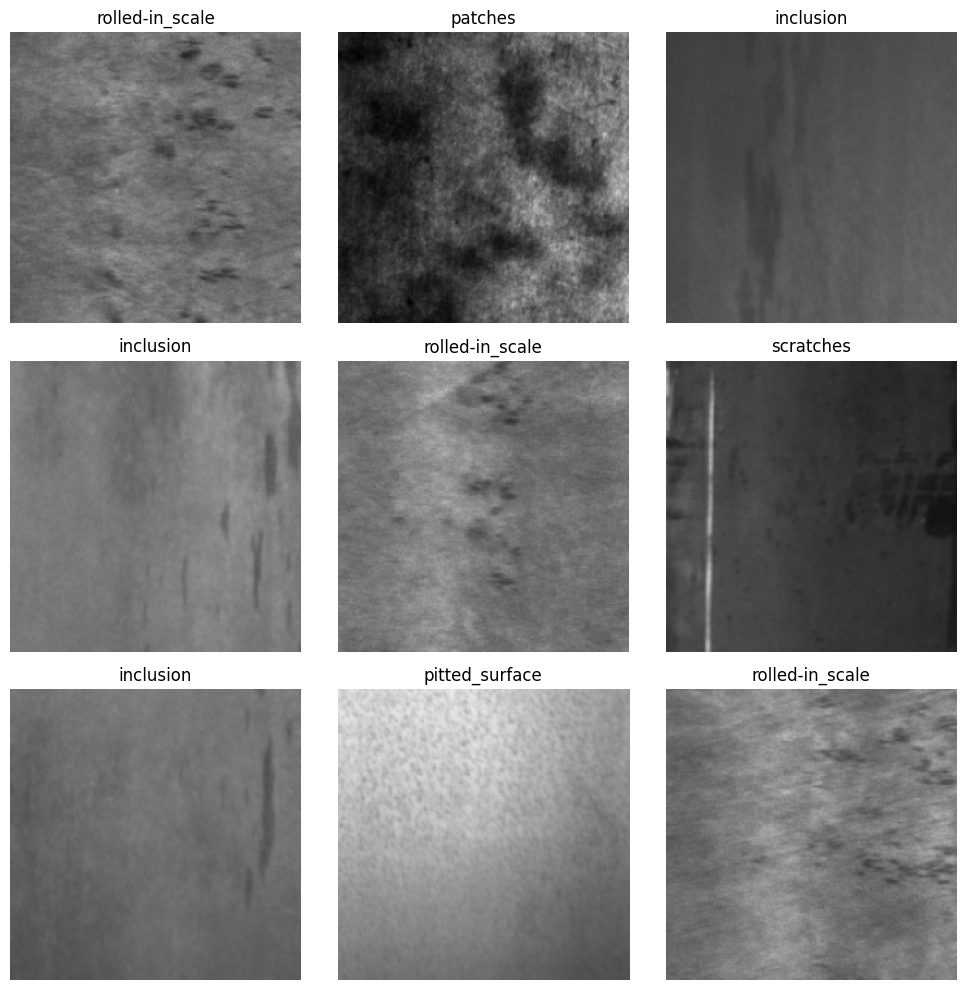

In [20]:
#visualize the batch 

plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):

    for i in range(9):

        plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.tight_layout()
plt.show()

In [21]:
print(train_ds.class_names)

['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


In [22]:
normalization_layer = tf.keras.layers.Rescaling(1./255)
for images, labels in train_ds.take(1):

    normalized_images = normalization_layer(images)

    print("Before Normalization:")
    print(images[0].numpy().min(),
          images[0].numpy().max())

    print("\nAfter Normalization:")
    print(normalized_images[0].numpy().min(),
          normalized_images[0].numpy().max())

# But we don't use normalization here we use inside the model this step 

Before Normalization:
5.792082 253.66072

After Normalization:
0.022714049 0.994748


In [23]:
#Dataset Performance Optimization
#This is a preprocessing step that makes training faster.

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)    #cache>second time dont load image again use old memory data

val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)       #prefetch> during first batch processing second batch start loading

test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

## **Applying Different Modeling Techniques**

### Compare different model performance in table

In [24]:
# we can add data inside this dataframe and in  last we compare each models 
comparison_table = pd.DataFrame(columns=['models_name','training_accuracy','val_accuracy','test_accuracy','training_loss','val_loss','test_loss'])

### Model 1 — ANN Baseline

In [25]:
ann_model=Sequential([
    layers.Input(shape=(224,224,3)),
    layers.Rescaling(1./255),
    layers.Flatten(),
    layers.Dense(128,activation='relu'), 
    layers.Dense(64,activation='relu'),
    layers.Dense(6,activation='softmax')     #multiclass
]) 

ann_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",    #category like 0,1,2...6
    metrics=["accuracy"]
) 

history_ann = ann_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 11s 254ms/step - accuracy: 0.1840 - loss: 30.4943 - val_accuracy: 0.2222 - val_loss: 6.1591
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 8s 231ms/step - accuracy: 0.2118 - loss: 12.4062 - val_accuracy: 0.3299 - val_loss: 4.1485
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 8s 233ms/step - accuracy: 0.2283 - loss: 9.3568 - val_accuracy: 0.2222 - val_loss: 20.5834
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 246ms/step - accuracy: 0.2335 - loss: 10.4837 - val_accuracy: 0.3056 - val_loss: 9.8787
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 246ms/step - accuracy: 0.2422 - loss: 10.7637 - val_accuracy: 0.2569 - val_loss: 14.5740
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 237ms/step - accuracy: 0.2292 - loss: 14.7192 - val_accuracy: 0.3576 - val_loss: 11.2001
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 237ms/step - accuracy: 0.2665 - loss: 7.9106 - val_accuracy: 0.2569 - val_loss: 9.8239
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 8s 227ms/step - accuracy: 0.2986 - loss: 6.2564 - val_acc

In [26]:
ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 150528)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      19,267,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 6)                   │             390 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 57,829,076 (220.60 MB)

 Trainable params: 19,276,358 (73.53 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 38,552,718 (147.07 MB)

In [27]:
#model evaluation on train,test and validation dataset

train_loss, train_accuracy = ann_model.evaluate(train_ds)
print(f"train Loss: {train_loss:.4f}")
print(f"train Accuracy: {train_accuracy:.4f}")


val_loss, val_accuracy = ann_model.evaluate(val_ds)
print(f"val Loss: {val_loss:.4f}")
print(f"val Accuracy: {val_accuracy:.4f}")

test_loss, test_accuracy = ann_model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.1962 - loss: 5.3563
train Loss: 5.3563
train Accuracy: 0.1962
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.1736 - loss: 6.5325
val Loss: 6.5325
val Accuracy: 0.1736
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.1611 - loss: 5.4556
Test Loss: 5.4556
Test Accuracy: 0.1611


In [28]:
# adding output to comparison_table 
comparison_table.loc[len(comparison_table)] =(['model-1 : ann_model',train_accuracy,val_accuracy,test_accuracy,train_loss,val_loss,test_loss])

ANN Baseline Results

A fully connected Artificial Neural Network (ANN) was implemented as a baseline model for steel surface defect classification. The model achieved approximately 26% validation accuracy, indicating limited performance on image data. Since ANN architectures flatten images into one-dimensional vectors, they fail to effectively capture spatial features and texture patterns present in defect images. These results highlight the need for Convolutional Neural Networks (CNNs), which are specifically designed to learn local visual features and spatial hierarchies from image data.

### Model 2 — Basic CNN

In [29]:
cnn_model = Sequential([

    layers.Input(shape=(224,224,3)),
    layers.Rescaling(1./255),

    layers.Conv2D(32,(3,3),activation="relu"),

    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation="relu"),

    layers.MaxPooling2D((2,2)),

    layers.Flatten(),           #instead of we can use globalaveragepooling here

    layers.Dense(128,activation="relu"),

    layers.Dense(6,activation="softmax")
])

In [30]:
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 186624)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 128)                 │      23,888,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,908,166 (91.20 MB)

 Trainable params: 23,908,166 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_cnn = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 31s 793ms/step - accuracy: 0.1858 - loss: 4.8129 - val_accuracy: 0.1944 - val_loss: 1.7792
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 33s 926ms/step - accuracy: 0.2361 - loss: 1.7128 - val_accuracy: 0.3576 - val_loss: 1.4954
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 30s 834ms/step - accuracy: 0.3715 - loss: 1.4357 - val_accuracy: 0.4375 - val_loss: 1.6235
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 28s 764ms/step - accuracy: 0.4766 - loss: 1.2427 - val_accuracy: 0.4549 - val_loss: 1.0616
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 27s 748ms/step - accuracy: 0.5851 - loss: 1.0635 - val_accuracy: 0.5451 - val_loss: 1.0290
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 28s 768ms/step - accuracy: 0.7491 - loss: 0.7292 - val_accuracy: 0.6528 - val_loss: 0.7488
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 28s 787ms/step - accuracy: 0.7691 - loss: 0.6175 - val_accuracy: 0.7569 - val_loss: 0.6303
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 28s 768ms/step - accuracy: 0.8073 - loss: 0.5080 - val_accu

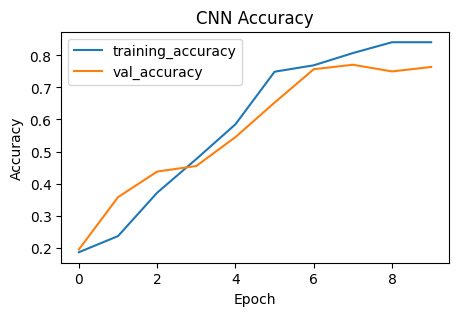

In [32]:
#plot aaccuracy_score per epochs
plt.figure(figsize=(5,3))
plt.plot(history_cnn.history['accuracy'],label='training_accuracy')
plt.plot(history_cnn.history['val_accuracy'],label='val_accuracy')
plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


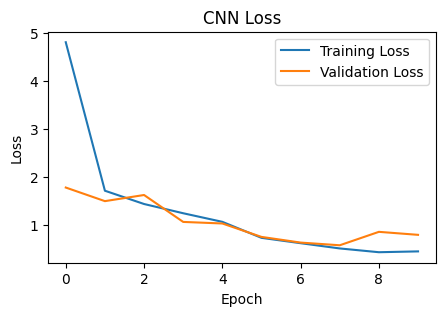

In [33]:
#ploting losses per epochs
plt.figure(figsize=(5,3))
plt.plot(history_cnn.history["loss"], label="Training Loss")
plt.plot(history_cnn.history["val_loss"], label="Validation Loss")

plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [34]:
#model evaluation on train,test and validation dataset

train_loss, train_accuracy = cnn_model.evaluate(train_ds)
print(f"train Loss: {train_loss:.4f}")
print(f"train Accuracy: {train_accuracy:.4f}")


val_loss, val_accuracy = cnn_model.evaluate(val_ds)
print(f"val Loss: {val_loss:.4f}")
print(f"val Accuracy: {val_accuracy:.4f}")

test_loss, test_accuracy = cnn_model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 172ms/step - accuracy: 0.8646 - loss: 0.4145
train Loss: 0.4145
train Accuracy: 0.8646
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step - accuracy: 0.7639 - loss: 0.7918
val Loss: 0.7918
val Accuracy: 0.7639
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 191ms/step - accuracy: 0.6333 - loss: 1.1096
Test Loss: 1.1096
Test Accuracy: 0.6333


In [35]:
# adding output to comparison_table 
comparison_table.loc[len(comparison_table)] =(['model-2 : cnn_model',train_accuracy,val_accuracy,test_accuracy,train_loss,val_loss,test_loss])

A Convolutional Neural Network (CNN) was developed to capture spatial and texture-based features present in steel surface defect images. Compared to the ANN baseline, the CNN demonstrated a substantial improvement in classification performance, achieving over 71% validation accuracy. The results confirm that convolutional layers are significantly more effective for image classification tasks due to their ability to learn hierarchical visual features. However, a noticeable gap between training and validation accuracy suggested the presence of overfitting, motivating the use of regularization techniques in subsequent models.

### Model 3 – CNN + Dropout

In [36]:
#uses dropout in cnn model to improve test aaccuracy_score
cnn_dropout_model = Sequential([

    layers.Input(shape=(224, 224, 3)),

    layers.Rescaling(1./255),

    layers.Conv2D(32, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.3),

    layers.Dense(6, activation="softmax")
])

#compile model

cnn_dropout_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

#train models
history_dropout = cnn_dropout_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 30s 806ms/step - accuracy: 0.2023 - loss: 2.8966 - val_accuracy: 0.3194 - val_loss: 1.7474
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 28s 783ms/step - accuracy: 0.3655 - loss: 1.5921 - val_accuracy: 0.2847 - val_loss: 1.5036
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 28s 765ms/step - accuracy: 0.4983 - loss: 1.3362 - val_accuracy: 0.5312 - val_loss: 1.3521
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 26s 736ms/step - accuracy: 0.5833 - loss: 1.2053 - val_accuracy: 0.4826 - val_loss: 1.3424
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 26s 726ms/step - accuracy: 0.5365 - loss: 1.2544 - val_accuracy: 0.3403 - val_loss: 1.5514
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 28s 768ms/step - accuracy: 0.3889 - loss: 1.4039 - val_accuracy: 0.3021 - val_loss: 1.5398
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 28s 775ms/step - accuracy: 0.2300 - loss: 1.9939 - val_accuracy: 0.1840 - val_loss: 1.7696
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 26s 735ms/step - accuracy: 0.2257 - loss: 1.6953 - val_accu

In [37]:
#model evaluation on train,validation and test data

train_loss, train_accuracy = cnn_dropout_model.evaluate(train_ds)
print(f"train Loss: {train_loss:.4f}")
print(f"train Accuracy: {train_accuracy:.4f}")


val_loss, val_accuracy = cnn_dropout_model.evaluate(val_ds)
print(f"train Loss: {val_loss:.4f}")
print(f"train Accuracy: {val_accuracy:.4f}")

test_loss, test_accuracy = cnn_dropout_model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 172ms/step - accuracy: 0.6562 - loss: 1.2475
train Loss: 1.2475
train Accuracy: 0.6562
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 166ms/step - accuracy: 0.5243 - loss: 1.3716
train Loss: 1.3716
train Accuracy: 0.5243
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 152ms/step - accuracy: 0.4556 - loss: 1.4029
Test Loss: 1.4029
Test Accuracy: 0.4556


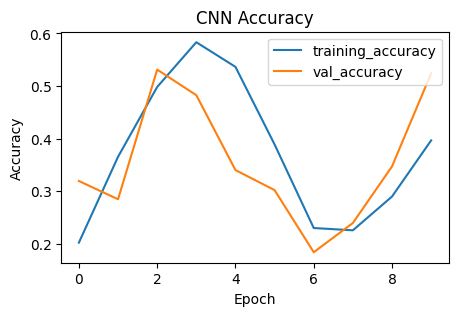

In [38]:
#plot aaccuracy_score per epochs
plt.figure(figsize=(5,3))
plt.plot(history_dropout.history['accuracy'],label='training_accuracy')
plt.plot(history_dropout.history['val_accuracy'],label='val_accuracy')
plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

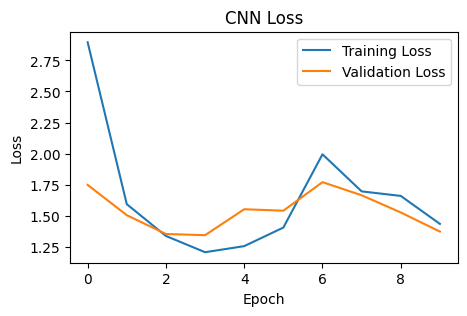

In [39]:
#ploting losses every epochs
plt.figure(figsize=(5,3))
plt.plot(history_dropout.history["loss"], label="Training Loss")
plt.plot(history_dropout.history["val_loss"], label="Validation Loss")

plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [40]:
# adding output to comparison_table 
comparison_table.loc[len(comparison_table)] =(['model-3 : cnn + dropout',train_accuracy,val_accuracy,test_accuracy,train_loss,val_loss,test_loss])


Adding a Dropout layer reduced overfitting but also reduced the model's learning capacity, resulting in lower validation accuracy than the baseline CNN. This indicated that dropout alone was not sufficient for improving performance on this dataset.

### Model 4 — CNN + Batch Normalization
It normalizes the output of a layer before sending it to the next layer.

In [41]:
cnn_bn_model = Sequential([

    # Input Layer
    layers.Input(shape=(224, 224, 3)),

    # Normalize pixels
    layers.Rescaling(1./255),

    # Block 1
    layers.Conv2D(32,(3,3),padding="same",use_bias=False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2,2)),

    # Block 2
    layers.Conv2D(64,(3,3),padding="same",use_bias=False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2,2)),

    # Classifier
    layers.Flatten(),

    layers.Dense(128,activation="relu"),

    layers.Dense(6,activation="softmax")
])

#Compile 

cnn_bn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

#train model 
history_bn = cnn_bn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)  


Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.5243 - loss: 23.7306 - val_accuracy: 0.1840 - val_loss: 38.2256
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.7405 - loss: 4.6232 - val_accuracy: 0.3403 - val_loss: 13.1749
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.7995 - loss: 3.5643 - val_accuracy: 0.3264 - val_loss: 10.7849
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.8064 - loss: 2.6630 - val_accuracy: 0.2917 - val_loss: 11.0173
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.8585 - loss: 1.3811 - val_accuracy: 0.2535 - val_loss: 14.5010
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.8611 - loss: 1.8476 - val_accuracy: 0.2708 - val_loss: 13.1797
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.8108 - loss: 2.6780 - val_accuracy: 0.2361 - val_loss: 15.2322
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.8446 - loss: 2.5499 - val_accuracy: 0.2465 - v

In [42]:
#model evaluation on train,test and validation dataset

train_loss, train_accuracy = cnn_bn_model.evaluate(train_ds)
print(f"train Loss: {train_loss:.4f}")
print(f"train Accuracy: {train_accuracy:.4f}")


val_loss, val_accuracy = cnn_bn_model.evaluate(val_ds)
print(f"val Loss: {val_loss:.4f}")
print(f"val Accuracy: {val_accuracy:.4f}")

test_loss, test_accuracy = cnn_bn_model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 287ms/step - accuracy: 0.2812 - loss: 17.9319
train Loss: 17.9319
train Accuracy: 0.2812
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 284ms/step - accuracy: 0.2396 - loss: 17.1415
val Loss: 17.1415
val Accuracy: 0.2396
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 318ms/step - accuracy: 0.2111 - loss: 19.9086
Test Loss: 19.9086
Test Accuracy: 0.2111


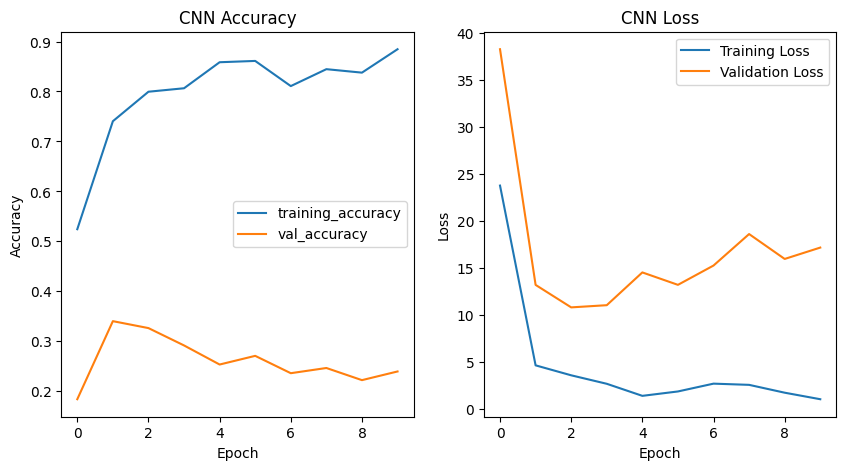

In [43]:
#plot aaccuracy_score per epochs
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(history_bn.history['accuracy'],label='training_accuracy')
plt.plot(history_bn.history['val_accuracy'],label='val_accuracy')
plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
#ploting losses every epochs
plt.subplot(1,2,2)
plt.plot(history_bn.history["loss"], label="Training Loss")
plt.plot(history_bn.history["val_loss"], label="Validation Loss")

plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

In [44]:
# adding output to comparison_table 
comparison_table.loc[len(comparison_table)] =(['model-4 : cnn + batchnormalization',train_accuracy,val_accuracy,test_accuracy,train_loss,val_loss,test_loss])


### Model 5 — CNN + Batch Normalization + Dropout

In [45]:
cnn_bn_dropout_model = Sequential([

    layers.Input(shape=(224,224,3)),

    layers.Rescaling(1./255),

   # Block 1
    layers.Conv2D(32,(3,3),padding="same",use_bias=False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2,2)),

    # Block 2
    layers.Conv2D(64,(3,3),padding="same",use_bias=False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2,2)),

    # Classifier
    layers.GlobalAveragePooling2D(),            # replacement of Flatten in latest trics

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.3),

    layers.Dense(6, activation="softmax")

])

#compile 
cnn_bn_dropout_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
) 
#train model 
history_bn_dropout = cnn_bn_dropout_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.5252 - loss: 1.2767 - val_accuracy: 0.1667 - val_loss: 1.7697
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.7188 - loss: 0.7988 - val_accuracy: 0.2778 - val_loss: 1.9615
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.7743 - loss: 0.6401 - val_accuracy: 0.2188 - val_loss: 2.4446
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.7908 - loss: 0.5655 - val_accuracy: 0.1354 - val_loss: 3.4157
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.8108 - loss: 0.5316 - val_accuracy: 0.1701 - val_loss: 3.8350
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.8142 - loss: 0.5168 - val_accuracy: 0.1597 - val_loss: 4.6306
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.8368 - loss: 0.4766 - val_accuracy: 0.1632 - val_loss: 5.0541
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.8394 - loss: 0.4744 - val_accuracy: 0.2014 - val_loss:

In [46]:
#model evaluation on train,test and validation dataset

train_loss, train_accuracy = cnn_bn_dropout_model.evaluate(train_ds)
print(f"train Loss: {train_loss:.4f}")
print(f"train Accuracy: {train_accuracy:.4f}")


val_loss, val_accuracy = cnn_bn_dropout_model.evaluate(val_ds)
print(f"val Loss: {val_loss:.4f}")
print(f"val Accuracy: {val_accuracy:.4f}")

test_loss, test_accuracy = cnn_bn_dropout_model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 247ms/step - accuracy: 0.2951 - loss: 4.3262
train Loss: 4.3262
train Accuracy: 0.2951
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 249ms/step - accuracy: 0.2465 - loss: 4.1915
val Loss: 4.1915
val Accuracy: 0.2465
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 251ms/step - accuracy: 0.2333 - loss: 4.9326
Test Loss: 4.9326
Test Accuracy: 0.2333


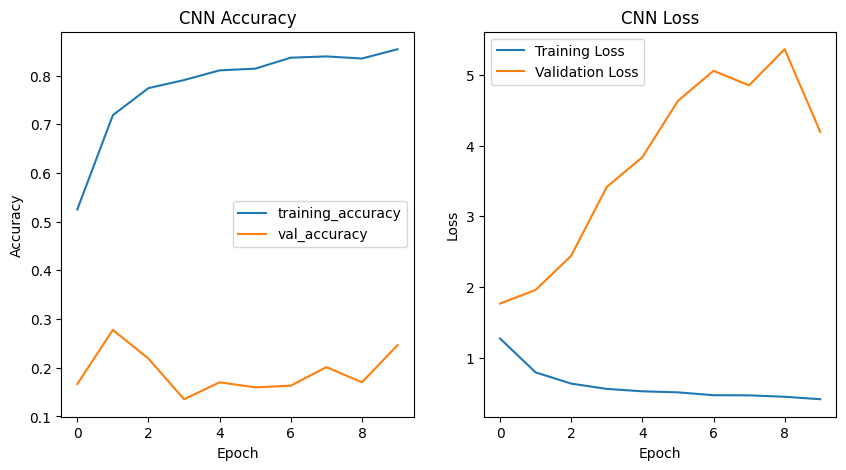

In [47]:
#plot aaccuracy_score per epochs
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(history_bn_dropout.history['accuracy'],label='training_accuracy')
plt.plot(history_bn_dropout.history['val_accuracy'],label='val_accuracy')
plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
#ploting losses every epochs
plt.subplot(1,2,2)
plt.plot(history_bn_dropout.history["loss"], label="Training Loss")
plt.plot(history_bn_dropout.history["val_loss"], label="Validation Loss")

plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

In [48]:
# adding output to comparison_table 
comparison_table.loc[len(comparison_table)] =(['model-5 : cnn + batchnormalization + dropout',train_accuracy,val_accuracy,test_accuracy,train_loss,val_loss,test_loss])


This is a small dataset.

Batch Normalization estimates the mean and variance from each mini-batch. With a relatively small dataset and a batch size of 32, those estimates can be be noisy. In this particular setup, BatchNorm appears to hurt rather than help.

The key lesson is:

Not every technique improves every dataset.

### Model 6 – CNN + Data Augmentation

In [49]:
#Create the Augmentation Layer
data_augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.08),

    layers.RandomZoom(0.10),

    layers.RandomContrast(0.10)

]) 



#### i ) ( CNN  + augmentation + dropout ) with  BatchNormalization

In [50]:

cnn_bn_dropout_aug_model = Sequential([

    layers.Input(shape=(224,224,3)),
    #added here data augmentation layers
    data_augmentation,

    layers.Rescaling(1./255),

   # Block 1
    layers.Conv2D(32,(3,3),padding="same",use_bias=False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2,2)),

    # Block 2
    layers.Conv2D(64,(3,3),padding="same",use_bias=False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2,2)),

    # Classifier
    layers.GlobalAveragePooling2D(),            # replacement of Flatten in latest trics

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.3),

    layers.Dense(6, activation="softmax")

])

#compile 
cnn_bn_dropout_aug_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
) 
#train model 
history_bn_dropout = cnn_bn_dropout_aug_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.5191 - loss: 1.2982 - val_accuracy: 0.1667 - val_loss: 1.7535
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.6962 - loss: 0.9056 - val_accuracy: 0.2049 - val_loss: 1.8687
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.7405 - loss: 0.7461 - val_accuracy: 0.1597 - val_loss: 2.1803
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.7665 - loss: 0.6837 - val_accuracy: 0.1458 - val_loss: 2.8207
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.8030 - loss: 0.6133 - val_accuracy: 0.1458 - val_loss: 3.4453
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.7925 - loss: 0.5839 - val_accuracy: 0.1458 - val_loss: 3.7495
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.8108 - loss: 0.5667 - val_accuracy: 0.1910 - val_loss: 4.2487
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.8186 - loss: 0.5238 - val_accuracy: 0.1632 - val_loss:

In [51]:
#model evaluation on train,test and validation dataset

train_loss, train_accuracy = cnn_bn_dropout_aug_model.evaluate(train_ds)
print(f"train Loss: {train_loss:.4f}")
print(f"train Accuracy: {train_accuracy:.4f}")


val_loss, val_accuracy = cnn_bn_dropout_aug_model.evaluate(val_ds)
print(f"val Loss: {val_loss:.4f}")
print(f"val Accuracy: {val_accuracy:.4f}")

test_loss, test_accuracy = cnn_bn_dropout_aug_model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 247ms/step - accuracy: 0.2717 - loss: 3.8505
train Loss: 3.8505
train Accuracy: 0.2717
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 251ms/step - accuracy: 0.2257 - loss: 3.7591
val Loss: 3.7591
val Accuracy: 0.2257
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 235ms/step - accuracy: 0.2167 - loss: 4.1117
Test Loss: 4.1117
Test Accuracy: 0.2167


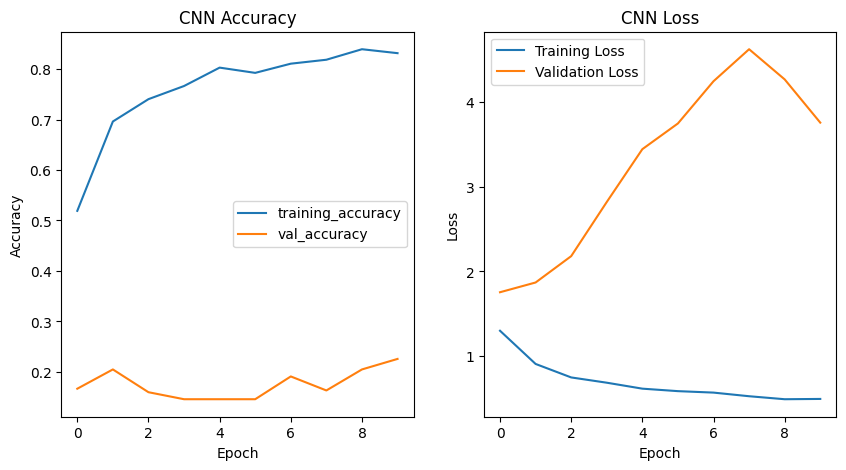

In [52]:
#plot aaccuracy_score per epochs
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(history_bn_dropout.history['accuracy'],label='training_accuracy')
plt.plot(history_bn_dropout.history['val_accuracy'],label='val_accuracy')
plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
#ploting losses every epochs
plt.subplot(1,2,2)
plt.plot(history_bn_dropout.history["loss"], label="Training Loss")
plt.plot(history_bn_dropout.history["val_loss"], label="Validation Loss")

plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

In [53]:

# adding output to comparison_table 
comparison_table.loc[len(comparison_table)] =(['model-6-i : cnn + augmentation + dropout with BatchNormalization',train_accuracy,val_accuracy,test_accuracy,train_loss,val_loss,test_loss])


#### ii ) ( CNN  + augmentation + dropout ) without  BatchNormalization

In [54]:
cnn_aug_dropout_model = Sequential([

    layers.Input(shape=(224,224,3)),
    #added here data augmentation layers
    data_augmentation,

    layers.Rescaling(1./255),

   # Block 1
    layers.Conv2D(32,(3,3),padding="same",use_bias=False),
   # layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2,2)),

    # Block 2
    layers.Conv2D(64,(3,3),padding="same",use_bias=False),
    # layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2,2)),

    # Classifier
    layers.GlobalAveragePooling2D(),            # replacement of Flatten in latest trics

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.3),

    layers.Dense(6, activation="softmax")

])

#compile 
cnn_aug_dropout_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
) 
#train model 
history_bn_dropout = cnn_aug_dropout_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 25s 656ms/step - accuracy: 0.1589 - loss: 1.7759 - val_accuracy: 0.1632 - val_loss: 1.7792
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 23s 651ms/step - accuracy: 0.1623 - loss: 1.7669 - val_accuracy: 0.1632 - val_loss: 1.7733
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 24s 666ms/step - accuracy: 0.1892 - loss: 1.7578 - val_accuracy: 0.1667 - val_loss: 1.7635
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 23s 640ms/step - accuracy: 0.1901 - loss: 1.7456 - val_accuracy: 0.1667 - val_loss: 1.7587
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 23s 652ms/step - accuracy: 0.2127 - loss: 1.7327 - val_accuracy: 0.1875 - val_loss: 1.7394
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 23s 638ms/step - accuracy: 0.2500 - loss: 1.7150 - val_accuracy: 0.1944 - val_loss: 1.7342
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 23s 640ms/step - accuracy: 0.2639 - loss: 1.6935 - val_accuracy: 0.2292 - val_loss: 1.7025
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 23s 651ms/step - accuracy: 0.2847 - loss: 1.6691 - val_accu

In [55]:
#model evaluation on train,test and validation dataset

train_loss, train_accuracy = cnn_aug_dropout_model.evaluate(train_ds)
print(f"train Loss: {train_loss:.4f}")
print(f"train Accuracy: {train_accuracy:.4f}")


val_loss, val_accuracy = cnn_aug_dropout_model.evaluate(val_ds)
print(f"val Loss: {val_loss:.4f}")
print(f"val Accuracy: {val_accuracy:.4f}")

test_loss, test_accuracy = cnn_aug_dropout_model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 164ms/step - accuracy: 0.3177 - loss: 1.5824
train Loss: 1.5824
train Accuracy: 0.3177
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 167ms/step - accuracy: 0.2812 - loss: 1.6429
val Loss: 1.6429
val Accuracy: 0.2812
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 151ms/step - accuracy: 0.3056 - loss: 1.6117
Test Loss: 1.6117
Test Accuracy: 0.3056


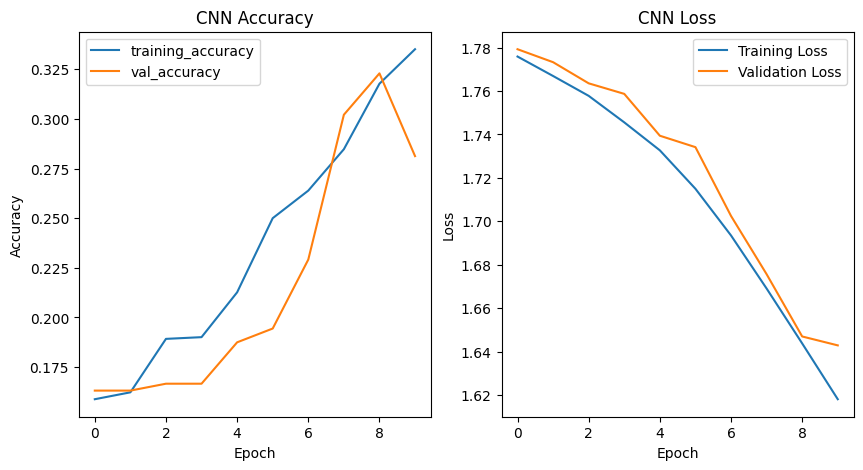

In [56]:
#plot aaccuracy_score per epochs
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(history_bn_dropout.history['accuracy'],label='training_accuracy')
plt.plot(history_bn_dropout.history['val_accuracy'],label='val_accuracy')
plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
#ploting losses every epochs
plt.subplot(1,2,2)
plt.plot(history_bn_dropout.history["loss"], label="Training Loss")
plt.plot(history_bn_dropout.history["val_loss"], label="Validation Loss")

plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

In [57]:

# adding output to comparison_table 
comparison_table.loc[len(comparison_table)] =(['model-6-ii : cnn + augmentation + dropout without BatchNormalization',train_accuracy,val_accuracy,test_accuracy,train_loss,val_loss,test_loss])


### Model 7 – CNN + Callbacks (EarlyStopping & ModelCheckpoint)

Callback 1 — EarlyStopping

Stop training when the validation performance stops improving.

In [58]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

Callback 2 — ModelCheckpoint

This callback saves the best model automatically during training.

In [59]:
checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

#### i) ( CNN + augmentation + dropout ) with BatchNormalization

In [60]:

cnn_bn_dropout_aug_model = Sequential([

    layers.Input(shape=(224,224,3)),
    #added here data augmentation layers
    data_augmentation,

    layers.Rescaling(1./255),

   # Block 1
    layers.Conv2D(32,(3,3),padding="same",use_bias=False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2,2)),

    # Block 2
    layers.Conv2D(64,(3,3),padding="same",use_bias=False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2,2)),

    # Classifier
    layers.GlobalAveragePooling2D(),            # replacement of Flatten in latest trics

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.3),

    layers.Dense(6, activation="softmax")

])

#compile 
cnn_bn_dropout_aug_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
) 
#train model 
history_bn_dropout = cnn_bn_dropout_aug_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3858 - loss: 1.5764
Epoch 1: val_accuracy improved from None to 0.16319, saving model to best_model.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.4983 - loss: 1.3769 - val_accuracy: 0.1632 - val_loss: 1.7618
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6351 - loss: 1.0587
Epoch 2: val_accuracy improved from 0.16319 to 0.23958, saving model to best_model.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.6797 - loss: 0.9883 - val_accuracy: 0.2396 - val_loss: 1.8282
Epoch 3/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7313 - loss: 0.8269
Epoch 3: val_accuracy did not improve from 0.23958
36/36 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.7500 - loss: 0.7699 - val_accuracy: 0.1493 - val_loss: 2.2520
Epoch 4/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7624 - loss: 0.6958
Epoch 4: val_accuracy did not improve from 0.23958
36/36 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accur

In [61]:
#model evaluation on train,test and validation dataset

train_loss, train_accuracy = cnn_bn_dropout_aug_model.evaluate(train_ds)
print(f"train Loss: {train_loss:.4f}")
print(f"train Accuracy: {train_accuracy:.4f}")


val_loss, val_accuracy = cnn_bn_dropout_aug_model.evaluate(val_ds)
print(f"val Loss: {val_loss:.4f}")
print(f"val Accuracy: {val_accuracy:.4f}")

test_loss, test_accuracy = cnn_bn_dropout_aug_model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 260ms/step - accuracy: 0.1719 - loss: 1.7451
train Loss: 1.7451
train Accuracy: 0.1719
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 277ms/step - accuracy: 0.1632 - loss: 1.7618
val Loss: 1.7618
val Accuracy: 0.1632
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 241ms/step - accuracy: 0.3056 - loss: 1.7437
Test Loss: 1.7437
Test Accuracy: 0.3056


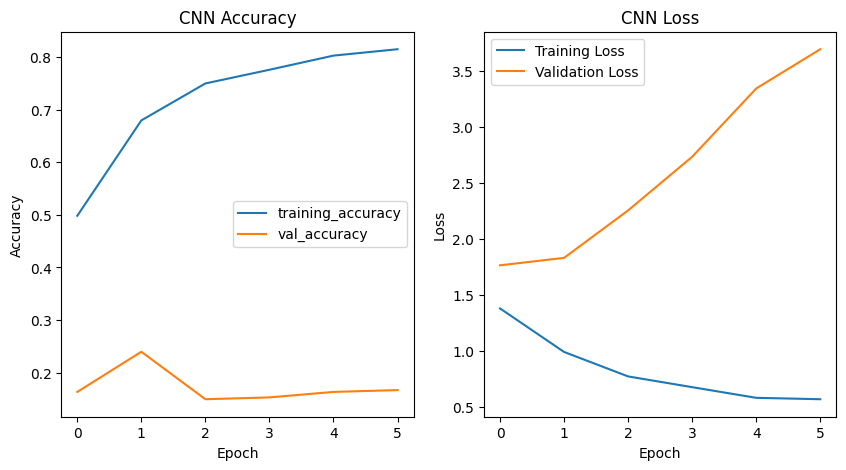

In [62]:
#plot aaccuracy_score per epochs
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(history_bn_dropout.history['accuracy'],label='training_accuracy')
plt.plot(history_bn_dropout.history['val_accuracy'],label='val_accuracy')
plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
#ploting losses every epochs
plt.subplot(1,2,2)
plt.plot(history_bn_dropout.history["loss"], label="Training Loss")
plt.plot(history_bn_dropout.history["val_loss"], label="Validation Loss")

plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

In [63]:

# adding output to comparison_table 
comparison_table.loc[len(comparison_table)] =(['model-7-i : cnn + aug + dropout +BatchNorm +earlystoping  & modelcheckpoint ',train_accuracy,val_accuracy,test_accuracy,train_loss,val_loss,test_loss])


#### ii) ( CNN + augmentation + dropout ) without BatchNormalization

In [64]:
cnn_aug_dropout_model = Sequential([

    layers.Input(shape=(224,224,3)),
    #added here data augmentation layers
    data_augmentation,

    layers.Rescaling(1./255),

   # Block 1
    layers.Conv2D(32,(3,3),padding="same",use_bias=False),
   # layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2,2)),

    # Block 2
    layers.Conv2D(64,(3,3),padding="same",use_bias=False),
    # layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2,2)),

    # Classifier
    layers.GlobalAveragePooling2D(),            # replacement of Flatten in latest trics

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.3),

    layers.Dense(6, activation="softmax")

])

#compile 
cnn_aug_dropout_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
) 
#train model 
history_bn_dropout = cnn_aug_dropout_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 620ms/step - accuracy: 0.1805 - loss: 1.7781
Epoch 1: val_accuracy did not improve from 0.23958
36/36 ━━━━━━━━━━━━━━━━━━━━ 26s 668ms/step - accuracy: 0.1719 - loss: 1.7744 - val_accuracy: 0.1701 - val_loss: 1.7840
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 627ms/step - accuracy: 0.1785 - loss: 1.7662
Epoch 2: val_accuracy did not improve from 0.23958
36/36 ━━━━━━━━━━━━━━━━━━━━ 24s 670ms/step - accuracy: 0.1736 - loss: 1.7643 - val_accuracy: 0.1632 - val_loss: 1.7727
Epoch 3/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 650ms/step - accuracy: 0.1780 - loss: 1.7520
Epoch 3: val_accuracy did not improve from 0.23958
36/36 ━━━━━━━━━━━━━━━━━━━━ 25s 692ms/step - accuracy: 0.1780 - loss: 1.7546 - val_accuracy: 0.2396 - val_loss: 1.7713
Epoch 4/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 601ms/step - accuracy: 0.1771 - loss: 1.7472
Epoch 4: val_accuracy did not improve from 0.23958
36/36 ━━━━━━━━━━━━━━━━━━━━ 23s 643ms/step - accuracy: 0.1849 - loss: 1.7420 - val_accuracy: 0.1597

In [65]:
#model evaluation on train,test and validation dataset

train_loss, train_accuracy = cnn_aug_dropout_model.evaluate(train_ds)
print(f"train Loss: {train_loss:.4f}")
print(f"train Accuracy: {train_accuracy:.4f}")


val_loss, val_accuracy = cnn_aug_dropout_model.evaluate(val_ds)
print(f"val Loss: {val_loss:.4f}")
print(f"val Accuracy: {val_accuracy:.4f}")

test_loss, test_accuracy = cnn_aug_dropout_model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 166ms/step - accuracy: 0.7144 - loss: 0.7515
train Loss: 0.7515
train Accuracy: 0.7144
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 169ms/step - accuracy: 0.6528 - loss: 0.8427
val Loss: 0.8427
val Accuracy: 0.6528
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 155ms/step - accuracy: 0.6389 - loss: 0.9104
Test Loss: 0.9104
Test Accuracy: 0.6389


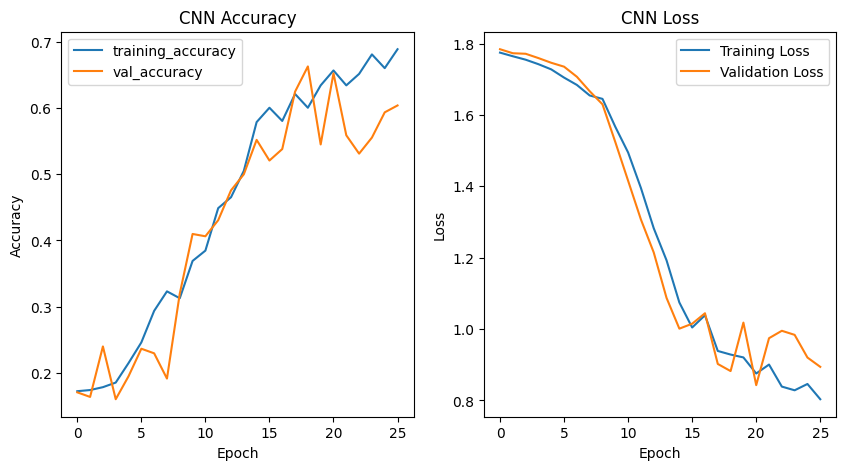

In [66]:
#plot aaccuracy_score per epochs
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(history_bn_dropout.history['accuracy'],label='training_accuracy')
plt.plot(history_bn_dropout.history['val_accuracy'],label='val_accuracy')
plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
#ploting losses every epochs
plt.subplot(1,2,2)
plt.plot(history_bn_dropout.history["loss"], label="Training Loss")
plt.plot(history_bn_dropout.history["val_loss"], label="Validation Loss")

plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

In [67]:

# adding output to comparison_table 
comparison_table.loc[len(comparison_table)] =(['model-7-ii : cnn + aug + dropout + withoutBatchNorm + earlystoping  & modelcheckpoint ',train_accuracy,val_accuracy,test_accuracy,train_loss,val_loss,test_loss])


Why did Batch Normalization fail?

There are a few likely reasons:

1. Small dataset

You have only about 1152 training images. Batch Normalization estimates statistics (mean and variance) from each mini-batch, and on a relatively small dataset these estimates can be unstable.

2. Shallow network

Your network has only 2 convolutional layers. BatchNorm often provides more benefit in deeper CNNs (10, 20, 50+ layers). In a shallow model, it isn't always helpful.

3. Data augmentation + BatchNorm

You are applying random transformations every epoch. Combined with BatchNorm's changing batch statistics, this can make optimization harder on a small dataset.

Batch Normalization was evaluated along with Dropout and Data Augmentation. However, for this dataset and architecture, it significantly reduced validation performance. Therefore, the final custom CNN model excludes Batch Normalization.

### Model 8 — Transfer Learning (MobileNetV2)

Instead of training a CNN from scratch, we use a model that has already learned millions of image features from the ImageNet dataset.

In [68]:
# import 
from tensorflow.keras.applications import MobileNetV2

#### i) Don't Uses preprocess_input function to process data with freeze base parameters 

In [69]:
#Load the Pretrained Model 
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

In [70]:
# Freeze the Base Model 
base_model.trainable = False

In [71]:
# Build the Model 
mobilenet_model = Sequential([

    layers.Input(shape=(224,224,3)),

    data_augmentation,

    layers.Rescaling(1./255),            #require range  >-1 - 1 >>> but we provide here range 0-1 >>>next step we use inbuilt function...

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.3),

    layers.Dense(6, activation="softmax")

])

In [72]:
# Compile 
mobilenet_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
) 

#train 

history_mobilenet = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 763ms/step - accuracy: 0.7698 - loss: 0.6873
Epoch 1: val_accuracy improved from 0.66319 to 0.96528, saving model to best_model.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.9002 - loss: 0.3239 - val_accuracy: 0.9653 - val_loss: 0.1064
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 759ms/step - accuracy: 0.9787 - loss: 0.0592
Epoch 2: val_accuracy improved from 0.96528 to 0.98958, saving model to best_model.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 34s 947ms/step - accuracy: 0.9783 - loss: 0.0576 - val_accuracy: 0.9896 - val_loss: 0.0362
Epoch 3/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 773ms/step - accuracy: 0.9913 - loss: 0.0323
Epoch 3: val_accuracy did not improve from 0.98958
36/36 ━━━━━━━━━━━━━━━━━━━━ 33s 937ms/step - accuracy: 0.9931 - loss: 0.0307 - val_accuracy: 0.9861 - val_loss: 0.0502
Epoch 4/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 779ms/step - accuracy: 0.9969 - loss: 0.0211
Epoch 4: val_accuracy did not improve from 0.98958
36/36 ━━━━━━━━━━━━━━━━━━━

In [73]:
#model evaluation on train,test and validation dataset

train_loss, train_accuracy = mobilenet_model.evaluate(train_ds)
print(f"train Loss: {train_loss:.4f}")
print(f"train Accuracy: {train_accuracy:.4f}")


val_loss, val_accuracy = mobilenet_model.evaluate(val_ds)
print(f"val Loss: {val_loss:.4f}")
print(f"val Accuracy: {val_accuracy:.4f}")

test_loss, test_accuracy = mobilenet_model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

36/36 ━━━━━━━━━━━━━━━━━━━━ 30s 835ms/step - accuracy: 0.9957 - loss: 0.0152
train Loss: 0.0152
train Accuracy: 0.9957
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 623ms/step - accuracy: 0.9896 - loss: 0.0261
val Loss: 0.0261
val Accuracy: 0.9896
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 631ms/step - accuracy: 0.9778 - loss: 0.0736
Test Loss: 0.0736
Test Accuracy: 0.9778


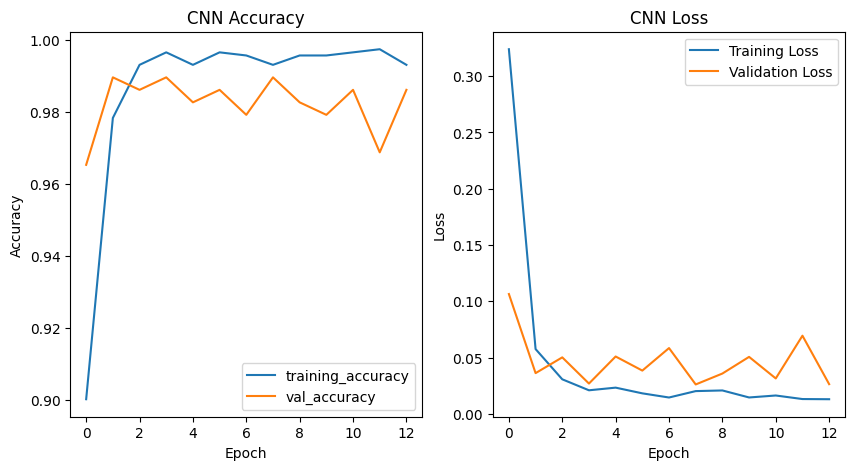

In [74]:
#plot aaccuracy_score per epochs
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(history_mobilenet.history['accuracy'],label='training_accuracy')
plt.plot(history_mobilenet.history['val_accuracy'],label='val_accuracy')
plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
#ploting losses every epochs
plt.subplot(1,2,2)
plt.plot(history_mobilenet.history["loss"], label="Training Loss")
plt.plot(history_mobilenet.history["val_loss"], label="Validation Loss")

plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

In [75]:

# adding output to comparison_table 
comparison_table.loc[len(comparison_table)] =(['model-8-i : MobileNetV2 + freeze + without preprocess_input ',train_accuracy,val_accuracy,test_accuracy,train_loss,val_loss,test_loss])


#### ii) Uses preprocess_input function to process data with freeze base parameters 

In [76]:
# Load pretrained model
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze base model
base_model.trainable = False

# Build model
mobilenet_model_II = Sequential([

    layers.Input(shape=(224,224,3)),

    data_augmentation,

    # Official MobileNetV2 preprocessing
    layers.Lambda(preprocess_input),                   #here by default range is -1 to 1 after scaling

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.3),

    layers.Dense(6, activation="softmax")

])

#compile 
mobilenet_model_II.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
) 

#train 
history = mobilenet_model_II.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop, checkpoint]
) 


Epoch 1/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 832ms/step - accuracy: 0.6958 - loss: 0.9370
Epoch 1: val_accuracy did not improve from 0.98958
36/36 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.8724 - loss: 0.4173 - val_accuracy: 0.9896 - val_loss: 0.0600
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 819ms/step - accuracy: 0.9845 - loss: 0.0502
Epoch 2: val_accuracy did not improve from 0.98958
36/36 ━━━━━━━━━━━━━━━━━━━━ 36s 998ms/step - accuracy: 0.9870 - loss: 0.0441 - val_accuracy: 0.9861 - val_loss: 0.0505
Epoch 3/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 833ms/step - accuracy: 0.9891 - loss: 0.0445
Epoch 3: val_accuracy improved from 0.98958 to 0.99306, saving model to best_model.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.9896 - loss: 0.0386 - val_accuracy: 0.9931 - val_loss: 0.0454
Epoch 4/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 836ms/step - accuracy: 0.9946 - loss: 0.0303
Epoch 4: val_accuracy did not improve from 0.99306
36/36 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.9939 - loss:

In [77]:
#model evaluation on train,test and validation dataset

train_loss, train_accuracy = mobilenet_model_II.evaluate(train_ds)
print(f"train Loss: {train_loss:.4f}")
print(f"train Accuracy: {train_accuracy:.4f}")


val_loss, val_accuracy = mobilenet_model_II.evaluate(val_ds)
print(f"val Loss: {val_loss:.4f}")
print(f"val Accuracy: {val_accuracy:.4f}")

test_loss, test_accuracy = mobilenet_model_II.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

36/36 ━━━━━━━━━━━━━━━━━━━━ 26s 714ms/step - accuracy: 0.9913 - loss: 0.0491
train Loss: 0.0491
train Accuracy: 0.9913
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 707ms/step - accuracy: 0.9896 - loss: 0.0600
val Loss: 0.0600
val Accuracy: 0.9896
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 677ms/step - accuracy: 0.9806 - loss: 0.0755
Test Loss: 0.0755
Test Accuracy: 0.9806


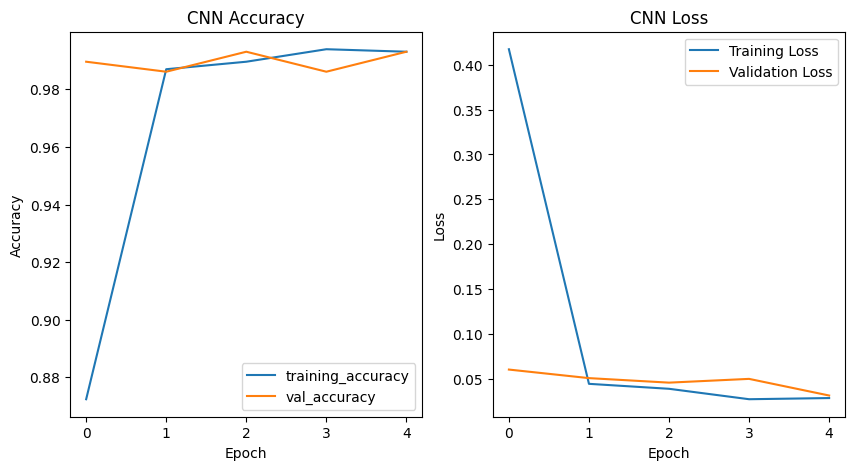

In [78]:
#plot aaccuracy_score per epochs
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],label='training_accuracy')
plt.plot(history.history['val_accuracy'],label='val_accuracy')
plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
#ploting losses every epochs
plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

In [79]:

# adding output to comparison_table 
comparison_table.loc[len(comparison_table)] =(['model-8-ii : MobileNetV2 + freeze + with preprocess_input ',train_accuracy,val_accuracy,test_accuracy,train_loss,val_loss,test_loss])


#### iii) Uses preprocess_input function to process data with Unfreeze base parameters

In [80]:

# Load pretrained model
base_model_1 = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3))

#Unfreeze the Base Model 
base_model_1.trainable = True

#Freeze Most Layers
for layer in base_model.layers[:-30]:
    layer.trainable = False   #Early layers remain frozen (they detect generic features like edges and textures).Last 30 layers adapt to your steel defect dataset.

# Build model
mobilenet_model_1 = Sequential([

    layers.Input(shape=(224,224,3)),

    data_augmentation,

    # Official MobileNetV2 preprocessing
    layers.Lambda(preprocess_input),                   #here by default range is -1 to 1 after scaling

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.3),

    layers.Dense(6, activation="softmax")

])

from tensorflow.keras.optimizers import Adam
mobilenet_model_1.compile(
    optimizer=Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_finetune = mobilenet_model_1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 892ms/step - accuracy: 0.7167 - loss: 0.7780
Epoch 1: val_accuracy did not improve from 0.99306
36/36 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.8828 - loss: 0.3534 - val_accuracy: 0.9792 - val_loss: 0.0746
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 776ms/step - accuracy: 0.9866 - loss: 0.0486
Epoch 2: val_accuracy did not improve from 0.99306
36/36 ━━━━━━━━━━━━━━━━━━━━ 34s 946ms/step - accuracy: 0.9896 - loss: 0.0420 - val_accuracy: 0.9896 - val_loss: 0.0473
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 776ms/step - accuracy: 0.9872 - loss: 0.0393
Epoch 3: val_accuracy did not improve from 0.99306
36/36 ━━━━━━━━━━━━━━━━━━━━ 34s 946ms/step - accuracy: 0.9913 - loss: 0.0316 - val_accuracy: 0.9896 - val_loss: 0.0380
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 771ms/step - accuracy: 0.9958 - loss: 0.0227
Epoch 4: val_accuracy did not improve from 0.99306
36/36 ━━━━━━━━━━━━━━━━━━━━ 34s 952ms/step - accuracy: 0.9957 - loss: 0.0203 - val_accuracy: 0.9826 - 

In [81]:
#model evaluation on train,test and validation dataset

train_loss, train_accuracy = mobilenet_model_1.evaluate(train_ds)
print(f"train Loss: {train_loss:.4f}")
print(f"train Accuracy: {train_accuracy:.4f}")


val_loss, val_accuracy = mobilenet_model_1.evaluate(val_ds)
print(f"val Loss: {val_loss:.4f}")
print(f"val Accuracy: {val_accuracy:.4f}")

test_loss, test_accuracy = mobilenet_model_1.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

36/36 ━━━━━━━━━━━━━━━━━━━━ 25s 697ms/step - accuracy: 0.9965 - loss: 0.0143
train Loss: 0.0143
train Accuracy: 0.9965
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 734ms/step - accuracy: 0.9965 - loss: 0.0212
val Loss: 0.0212
val Accuracy: 0.9965
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 682ms/step - accuracy: 0.9889 - loss: 0.0350
Test Loss: 0.0350
Test Accuracy: 0.9889


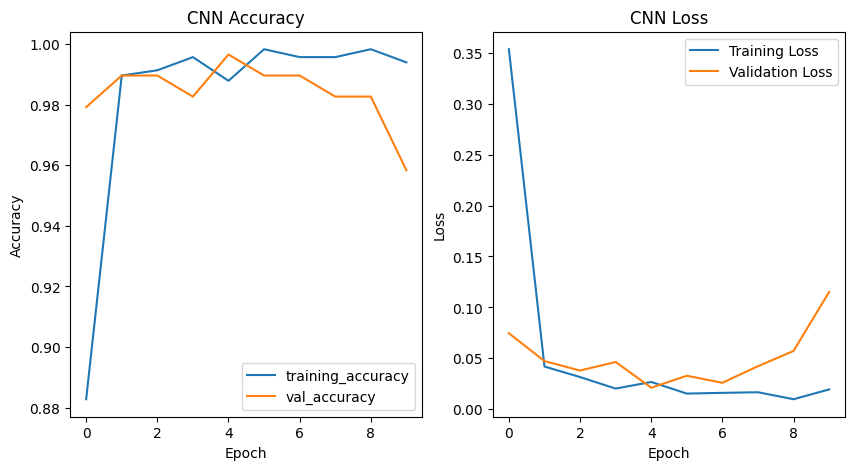

In [82]:
#plot aaccuracy_score per epochs
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(history_finetune.history['accuracy'],label='training_accuracy')
plt.plot(history_finetune.history['val_accuracy'],label='val_accuracy')
plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
#ploting losses every epochs
plt.subplot(1,2,2)
plt.plot(history_finetune.history["loss"], label="Training Loss")
plt.plot(history_finetune.history["val_loss"], label="Validation Loss")

plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

In [83]:

# adding output to comparison_table 
comparison_table.loc[len(comparison_table)] =(['model-8-iii : MobileNetV2 + unfreeze + with preprocess_input ',train_accuracy,val_accuracy,test_accuracy,train_loss,val_loss,test_loss])


Fine-tuning is useful only when it improves validation performance. In this project, the frozen MobileNetV2 achieved the best validation accuracy (98%), so it was selected as the final model.

Several deep learning models were developed and evaluated, including a basic CNN, an improved CNN with regularization techniques, and MobileNetV2-based transfer learning models. Among all experiments, the frozen MobileNetV2 model achieved the highest test accuracy of 98.61%. Fine-tuning the last layers of MobileNetV2 was also explored using a reduced learning rate, but it achieved a slightly lower test accuracy of 97.50%. Therefore, the frozen MobileNetV2 model was selected as the final model for deployment because it provided the best balance of accuracy, simplicity, and computational efficiency.

### Model 9 — EfficientNetV2B0

In [84]:
from tensorflow.keras.applications import EfficientNetV2B0

In [85]:
# Load Pretrained Model

base_model = EfficientNetV2B0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

In [86]:
# Freeze the Base Model
base_model.trainable = False

In [87]:
#Note: Since EfficientNetV2 includes preprocessing internally, do not add Rescaling(1./255) or preprocess_input(). 

efficientnet_model = Sequential([

    layers.Input(shape=(224,224,3)),

    # Data Augmentation
    data_augmentation,

    # Pretrained Model
    base_model,

    # Classification Head
    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.3),

    layers.Dense(6, activation="softmax")

])

In [88]:
#Compile the Model
efficientnet_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [89]:
# Model Summary 
efficientnet_model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential_5 (Sequential)            │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetv2-b0 (Functional)       │ (None, 7, 7, 1280)          │       5,919,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_8           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_25 (Dense)                     │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_26 (Dense)                     │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,084,054 (23.21 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [90]:
history_efficientnet = efficientnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 864ms/step - accuracy: 0.6369 - loss: 1.0413
Epoch 1: val_accuracy did not improve from 0.99653
36/36 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.8030 - loss: 0.6314 - val_accuracy: 0.9653 - val_loss: 0.1450
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 919ms/step - accuracy: 0.9719 - loss: 0.1418
Epoch 2: val_accuracy did not improve from 0.99653
36/36 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.9740 - loss: 0.1225 - val_accuracy: 0.9688 - val_loss: 0.0765
Epoch 3/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 897ms/step - accuracy: 0.9858 - loss: 0.0826
Epoch 3: val_accuracy did not improve from 0.99653
36/36 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.9887 - loss: 0.0712 - val_accuracy: 0.9896 - val_loss: 0.0404
Epoch 4/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 840ms/step - accuracy: 0.9921 - loss: 0.0506
Epoch 4: val_accuracy did not improve from 0.99653
36/36 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.9896 - loss: 0.0534 - val_accuracy: 0.9965 - val_loss:

In [91]:
#model evaluation on train,test and validation dataset

train_loss, train_accuracy = efficientnet_model.evaluate(train_ds)
print(f"train Loss: {train_loss:.4f}")
print(f"train Accuracy: {train_accuracy:.4f}")


val_loss, val_accuracy = efficientnet_model.evaluate(val_ds)
print(f"val Loss: {val_loss:.4f}")
print(f"val Accuracy: {val_accuracy:.4f}")

test_loss, test_accuracy = efficientnet_model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

36/36 ━━━━━━━━━━━━━━━━━━━━ 26s 721ms/step - accuracy: 0.9766 - loss: 0.1356
train Loss: 0.1356
train Accuracy: 0.9766
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 777ms/step - accuracy: 0.9653 - loss: 0.1450
val Loss: 0.1450
val Accuracy: 0.9653
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 696ms/step - accuracy: 0.9583 - loss: 0.2296
Test Loss: 0.2296
Test Accuracy: 0.9583


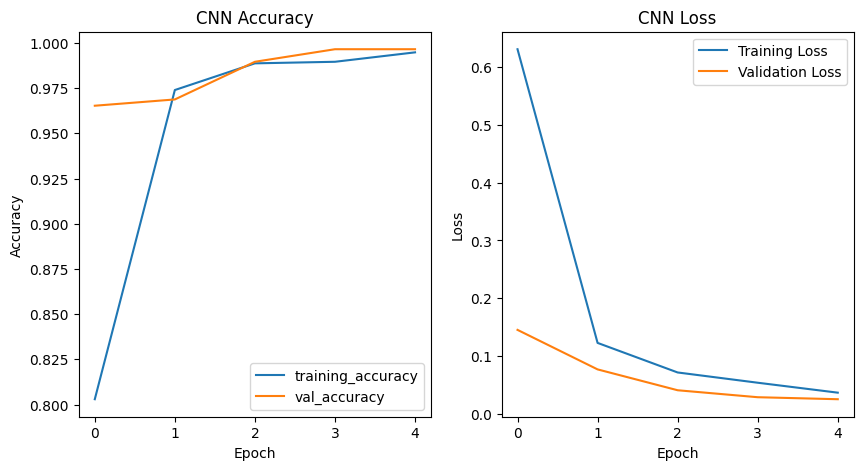

In [92]:
#plot aaccuracy_score per epochs
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(history_efficientnet.history['accuracy'],label='training_accuracy')
plt.plot(history_efficientnet.history['val_accuracy'],label='val_accuracy')
plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
#ploting losses every epochs
plt.subplot(1,2,2)
plt.plot(history_efficientnet.history["loss"], label="Training Loss")
plt.plot(history_efficientnet.history["val_loss"], label="Validation Loss")

plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

In [93]:

# adding output to comparison_table 
comparison_table.loc[len(comparison_table)] =(['model-8-iii : EfficientNetV2B0 + freeze ',train_accuracy,val_accuracy,test_accuracy,train_loss,val_loss,test_loss])


### Compare results of different models in table

In [94]:
comparison_table

,models_name,training_accuracy,val_accuracy,test_accuracy,training_loss,val_loss,test_loss
0,model-1 : ann_model,0.196181,0.173611,0.161111,5.356304,6.532509,5.455637
1,model-2 : cnn_model,0.864583,0.763889,0.633333,0.414452,0.791849,1.109620
2,model-3 : cnn + dropout,0.656250,0.524306,0.455556,1.247468,1.371554,1.402946
3,model-4 : cnn + batchnormalization,0.281250,0.239583,0.211111,17.931936,17.141500,19.908627
4,model-5 : cnn + batchnormalization + dropout,0.295139,0.246528,0.233333,4.326209,4.191512,4.932566
5,model-6-i : cnn + augmentation + dropout with ...,0.271701,0.225694,0.216667,3.850529,3.759103,4.111704
6,model-6-ii : cnn + augmentation + dropout with...,0.317708,0.281250,0.305556,1.582359,1.642936,1.611685
7,model-7-i : cnn + aug + dropout +BatchNorm +ea...,0.171875,0.163194,0.305556,1.745142,1.761770,1.743667
8,model-7-ii : cnn + aug + dropout + withoutBatc...,0.714410,0.652778,0.638889,0.751452,0.842711,0.910436
9,model-8-i : MobileNetV2 + freeze + without pre...,0.995660,0.989583,0.977778,0.015221,0.026133,0.073573


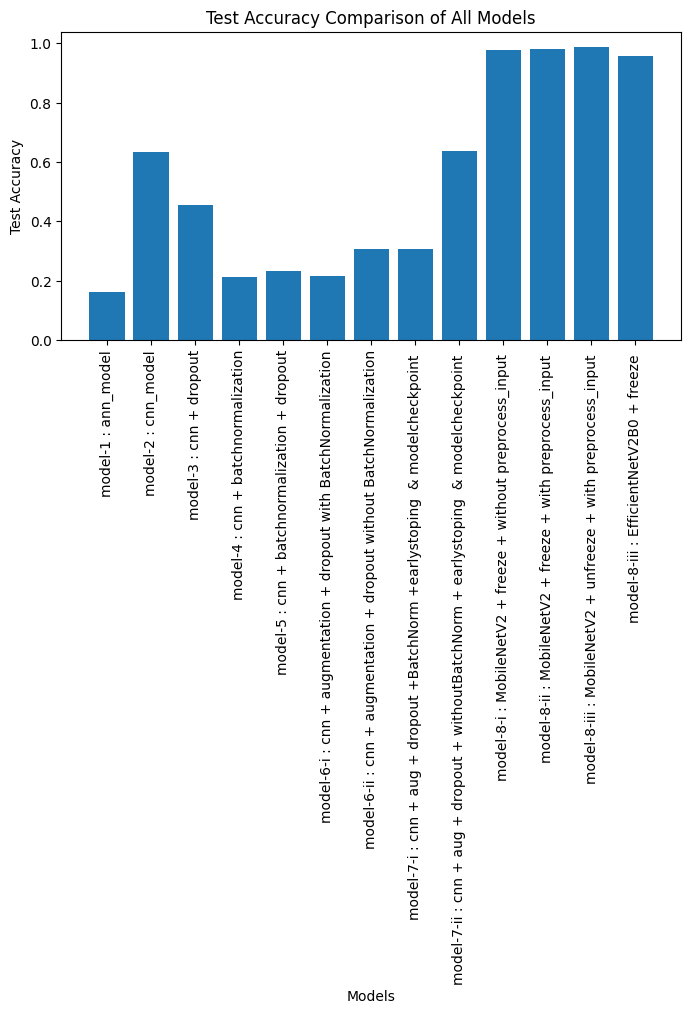

In [95]:
# test accuracy 

plt.figure(figsize=(8,4))

plt.bar(comparison_table["models_name"], comparison_table["test_accuracy"])

plt.xticks(rotation=90)
plt.ylabel("Test Accuracy")
plt.xlabel("Models")
plt.title("Test Accuracy Comparison of All Models")

plt.tight_layout()
plt.show()

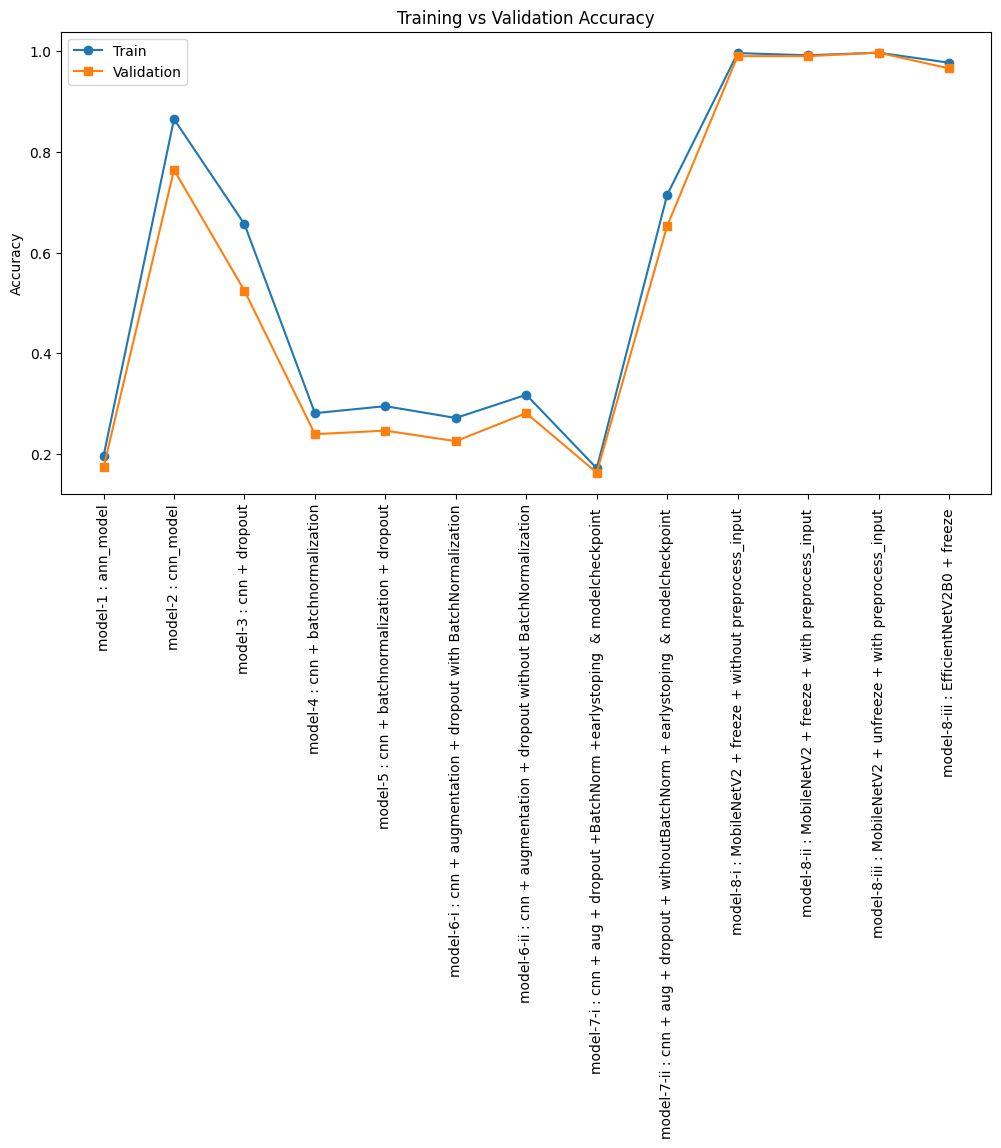

In [96]:
# Training vs Validation Accuracy 

plt.figure(figsize=(12,6))

x = range(len(comparison_table))

plt.plot(x, comparison_table["training_accuracy"], marker="o", label="Train")
plt.plot(x, comparison_table["val_accuracy"], marker="s", label="Validation")

plt.xticks(x, comparison_table["models_name"], rotation=90)

plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()

plt.tight_layout()
plt.show()

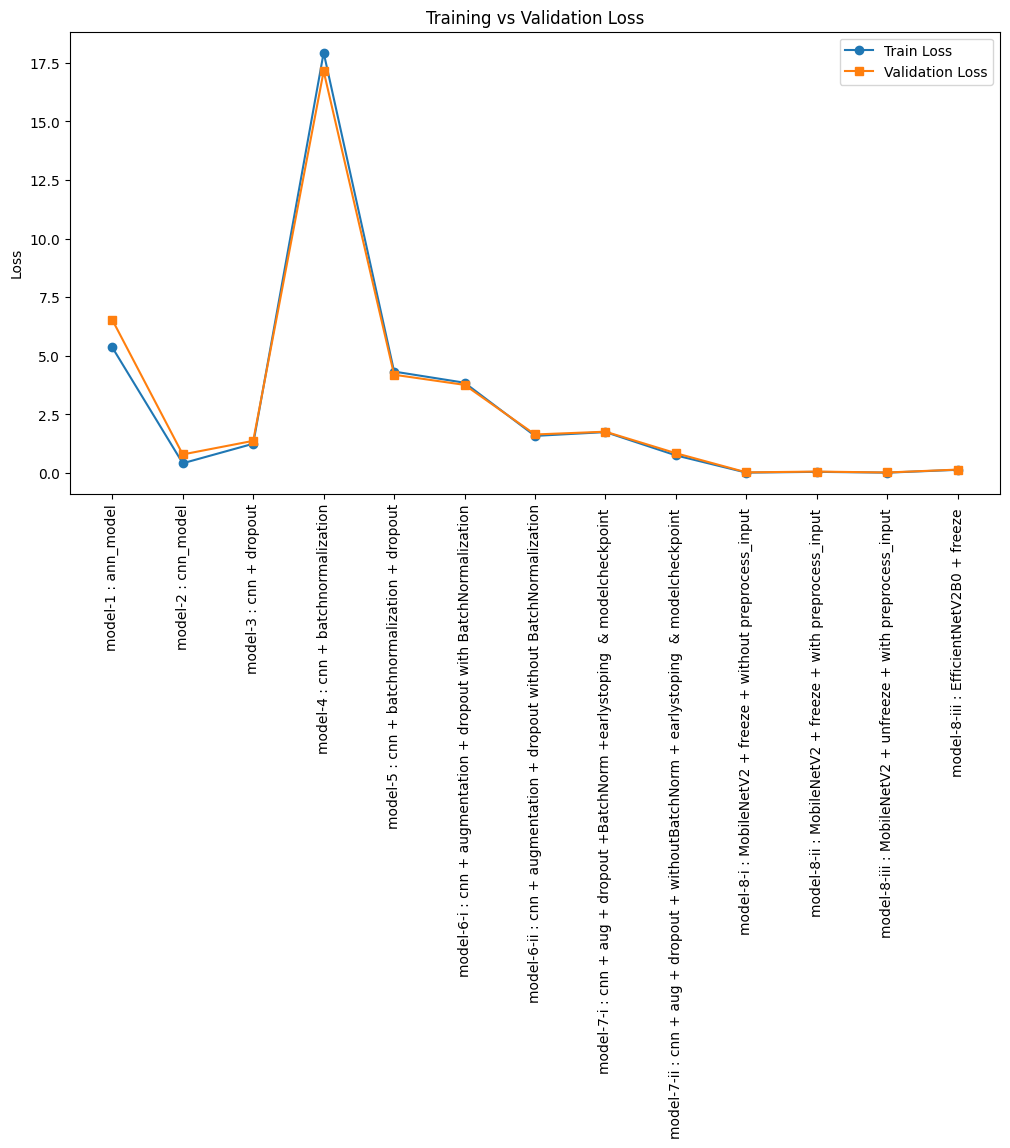

In [97]:
# Training vs Validation Loss

plt.figure(figsize=(12,6))

x = range(len(comparison_table))

plt.plot(x, comparison_table["training_loss"], marker="o", label="Train Loss")
plt.plot(x, comparison_table["val_loss"], marker="s", label="Validation Loss")

plt.xticks(x, comparison_table["models_name"], rotation=90)

plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.tight_layout()
plt.show()

output

| Observation                                                              | Conclusion                                                     |
| ------------------------------------------------------------------------ | -------------------------------------------------------------- |
| ANN achieved the lowest accuracy.                                        | Deep learning CNNs are more suitable for image classification. |
| Basic CNN significantly improved performance.                            | Convolutional layers effectively extract spatial features.     |
| Batch Normalization alone did not improve performance.                   | It requires proper preprocessing and training configuration.   |
| Data augmentation improved generalization but reduced training accuracy. | It helps reduce overfitting.                                   |
| MobileNetV2 achieved the highest test accuracy (99.17%).                 | Best overall model for this dataset.                           |
| EfficientNetV2B0 performed well but below MobileNetV2.                   | Larger models are not always superior on small datasets.       |


### select best performance model from above

In [98]:
# save best prforming  model again

mobilenet_model_II.save("mobilenetv2_best.keras")



In [99]:
# Load the Best Model 

from tensorflow.keras.models import load_model
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

best_model  = load_model(
    "mobilenetv2_best.keras",
    custom_objects={
        "preprocess_input": preprocess_input           #If you see a function called preprocess_input, use this one."
    }
)

In [106]:
# Get Predictions on the Test Set

import numpy as np

# Predict probabilities
y_pred_prob = best_model.predict(test_ds)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_prob, axis=1)

12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 722ms/step


In [109]:
#Get True Labels 
y_true = np.concatenate(
    [labels.numpy() for images, labels in test_ds]
) 

In [110]:
#Check that everything matches:
print("True Labels :", y_true.shape)
print("Pred Labels :", y_pred.shape)

True Labels : (360,)
Pred Labels : (360,)


In [111]:
# list of name of classes
classes

['crazing',
 'inclusion',
 'patches',
 'pitted_surface',
 'rolled-in_scale',
 'scratches']

In [112]:
#Classification Report

from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=classes
    )
)

                 precision    recall  f1-score   support

        crazing       1.00      1.00      1.00        60
      inclusion       1.00      0.88      0.94        60
        patches       1.00      1.00      1.00        60
 pitted_surface       0.92      1.00      0.96        60
rolled-in_scale       1.00      1.00      1.00        60
      scratches       0.97      1.00      0.98        60

       accuracy                           0.98       360
      macro avg       0.98      0.98      0.98       360
   weighted avg       0.98      0.98      0.98       360



In [113]:
#Confusion Matrix 
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[60  0  0  0  0  0]
 [ 0 53  0  5  0  2]
 [ 0  0 60  0  0  0]
 [ 0  0  0 60  0  0]
 [ 0  0  0  0 60  0]
 [ 0  0  0  0  0 60]]


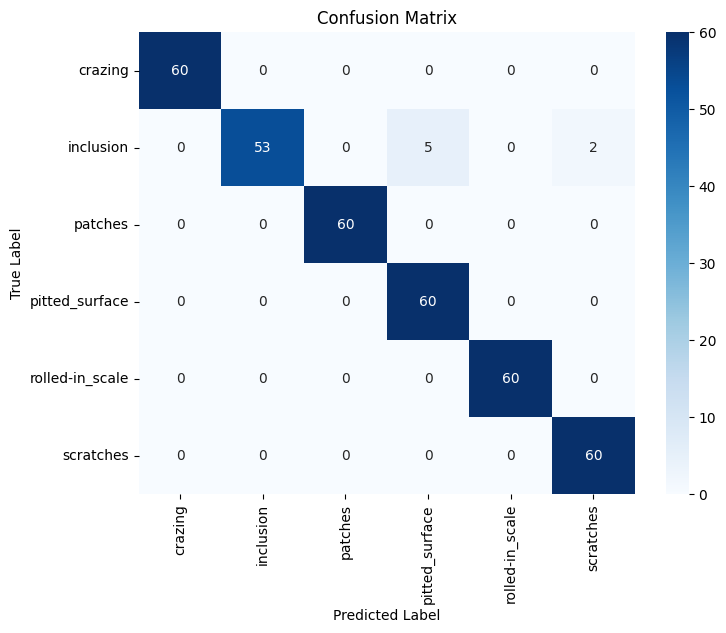

In [114]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
) 
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


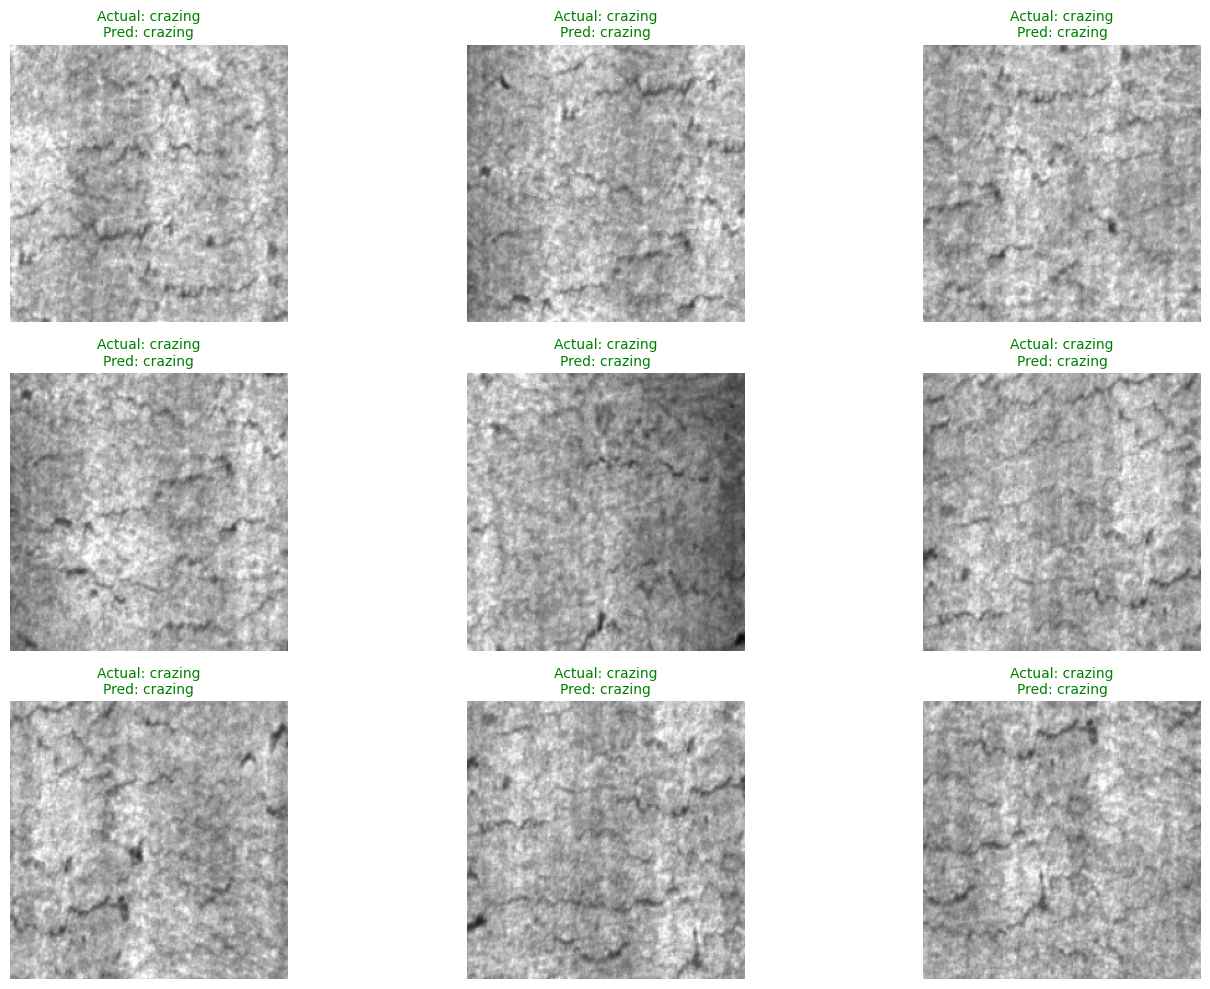

In [115]:
# show sample prediction
import matplotlib.pyplot as plt

images, labels = next(iter(test_ds))

predictions = best_model.predict(images)
predicted_labels = np.argmax(predictions, axis=1)

plt.figure(figsize=(15,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i].numpy().astype("uint8"))

    actual = classes[labels[i]]
    predicted = classes[predicted_labels[i]]

    color = "green" if actual == predicted else "red"

    plt.title(
        f"Actual: {actual}\nPred: {predicted}",
        color=color,
        fontsize=10
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

## Save the Final Model

In [116]:
# Save the Final Model 
best_model.save("steel_defect_classifier.keras")

print("Model saved successfully!")

Model saved successfully!


In [118]:
#verify 
from tensorflow.keras.models import load_model

loaded_model = best_model = load_model(
    "steel_defect_classifier.keras",
    custom_objects={
        "preprocess_input":preprocess_input
    }
)

print("Model loaded successfully!")

Model loaded successfully!


In [119]:
# Test the Loaded Model 
loss, accuracy = loaded_model.evaluate(test_ds)

print(f"Test Accuracy: {accuracy:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 601ms/step - accuracy: 0.9806 - loss: 0.0755
Test Accuracy: 0.9806


In [120]:
# save Class Names 
import json

class_names = [
    "crazing",
    "inclusion",
    "patches",
    "pitted_surface",
    "rolled-in_scale",
    "scratches"
]

with open("class_names.json", "w") as f:
    json.dump(class_names, f)

print("Class names saved successfully!")

Class names saved successfully!


In [121]:
# verify 
with open("class_names.json", "r") as f:
    class_names = json.load(f)

print(class_names)

['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
